In [1]:
import pandas as pd

In [2]:
scoredata = pd.read_csv('tetra-nag_side_0_energy_5000p_scoredata.csv', index_col='model_num')
scoredata.head()

,Fnat,Fnat_intf_residues,glycan_Jump_res,heavy_Lrmsd,heavy_Srmsd,interaction_energy,mc_acceptance,n_intf_res_contacts,n_intf_residues,n_nat_intf_res_contacts,...,n_rb_cycles,n_rb_moves_accepted,n_rb_moves_made,n_tor_cycles,n_tor_moves_accepted,n_tor_moves_made,ring_Lrmsd,ring_Srmsd,pose_file,cluster_id
model_num,,,,,,,,,,,,,,,,,,,,,
1,0.000000,0.000000,525.0,8.97622,0.609518,-3.381160,0.300000,5.0,6.0,0.0,...,2.0,12.0,40.0,0.0,0.0,0.0,9.48114,2.433350e-08,/projects/SimBioSys/jkant/glycographer/dc-sign...,NaN
2,1.000000,1.000000,525.0,4.20544,0.473391,-4.528200,0.250000,4.0,5.0,3.0,...,4.0,20.0,80.0,0.0,0.0,0.0,3.85436,4.235710e-07,/projects/SimBioSys/jkant/glycographer/dc-sign...,NaN
3,0.333333,0.333333,525.0,5.29441,0.469820,-0.694916,0.333333,1.0,2.0,1.0,...,6.0,40.0,120.0,0.0,0.0,0.0,4.83756,2.698720e-07,/projects/SimBioSys/jkant/glycographer/dc-sign...,NaN
4,0.500000,0.500000,525.0,4.89733,0.571189,-3.753540,0.312500,2.0,3.0,2.0,...,8.0,50.0,160.0,0.0,0.0,0.0,4.70414,4.214680e-08,/projects/SimBioSys/jkant/glycographer/dc-sign...,NaN
5,1.000000,1.000000,525.0,5.06993,0.564116,-3.839560,0.280000,5.0,6.0,2.0,...,10.0,56.0,200.0,0.0,0.0,0.0,2.56400,2.433350e-08,/projects/SimBioSys/jkant/glycographer/dc-sign...,NaN


In [6]:
poses_q1 = scoredata[scoredata['interaction_energy'] <= -8.503]
poses_q2 = scoredata[(scoredata['interaction_energy'] <= -6.929) & (scoredata['interaction_energy'] > -8.503)]
poses_q3 = scoredata[(scoredata['interaction_energy'] <= -5.355) & (scoredata['interaction_energy'] > -6.929)]
poses_q4 = scoredata[(scoredata['interaction_energy'] <= -3.78) & (scoredata['interaction_energy'] > -5.355)]

poses_q3.head()

,Fnat,Fnat_intf_residues,glycan_Jump_res,heavy_Lrmsd,heavy_Srmsd,interaction_energy,mc_acceptance,n_intf_res_contacts,n_intf_residues,n_nat_intf_res_contacts,...,n_rb_cycles,n_rb_moves_accepted,n_rb_moves_made,n_tor_cycles,n_tor_moves_accepted,n_tor_moves_made,ring_Lrmsd,ring_Srmsd,pose_file,cluster_id
model_num,,,,,,,,,,,,,,,,,,,,,
9,1.000000,1.000000,525.0,5.14149,0.076629,-5.90922,0.269444,2.0,3.0,2.0,...,18.0,97.0,360.0,0.0,0.0,0.0,2.76164,3.209810e-07,/projects/SimBioSys/jkant/glycographer/dc-sign...,2.0
13,0.625000,0.625000,525.0,3.60154,0.284869,-6.70252,0.303846,5.0,6.0,4.0,...,26.0,158.0,520.0,0.0,0.0,0.0,3.21111,0.000000e+00,/projects/SimBioSys/jkant/glycographer/dc-sign...,NaN
76,0.000000,0.000000,525.0,6.30790,0.267062,-5.81182,0.313158,1.0,2.0,0.0,...,152.0,952.0,3040.0,0.0,0.0,0.0,6.15350,3.441280e-08,/projects/SimBioSys/jkant/glycographer/dc-sign...,15.0
83,0.500000,0.500000,525.0,5.07900,0.482788,-6.70491,0.317169,4.0,5.0,3.0,...,166.0,1053.0,3320.0,0.0,0.0,0.0,3.92686,3.116210e-07,/projects/SimBioSys/jkant/glycographer/dc-sign...,5.0
87,0.714286,0.714286,525.0,4.54584,0.628746,-6.53987,0.312644,7.0,8.0,4.0,...,174.0,1088.0,3480.0,0.0,0.0,0.0,4.38011,7.039910e-07,/projects/SimBioSys/jkant/glycographer/dc-sign...,19.0


In [7]:
models_q1 = poses_q1.index
models_q2 = poses_q2.index
models_q3 = poses_q3.index
models_q4 = poses_q4.index

n_poses_q1 = len(models_q1)
n_poses_q2 = len(models_q2)
n_poses_q3 = len(models_q3)
n_poses_q4 = len(models_q4)

print(n_poses_q1)
print(n_poses_q2)
print(n_poses_q3)
print(n_poses_q4)

26
200
317
715


In [ ]:
from typing import List

def get_models_by_hotspot_bins(scoredata:str, isovalues:List):
    df = pd.read_csv(scoredata, index_col='model_num')
    #isovalues = isovalues.sort()
    model_groups = {}
    for i in range(len(isovalues)-1):
        # Possibly need a way to split these better
        group = df[(df['interaction_energy'] <= isovalues[i+1]) & (df['interaction_energy'] > isovalues[i])]
        model_groups[f'q_{i}'] = group
    return model_groups

In [22]:
scoredata = 'tetra-nag12man_side_0_energy_5000p_scoredata.csv'
isovalues = [-10.826, -9.1, -7.373, -5.647, -3.92]

model_groups = get_models_by_hotspot_bins(scoredata, isovalues)

for key, val in model_groups.items():
    print(f'{key} : {len(val)} total models')

q_0 : 15 total models
q_1 : 58 total models
q_2 : 227 total models
q_3 : 767 total models


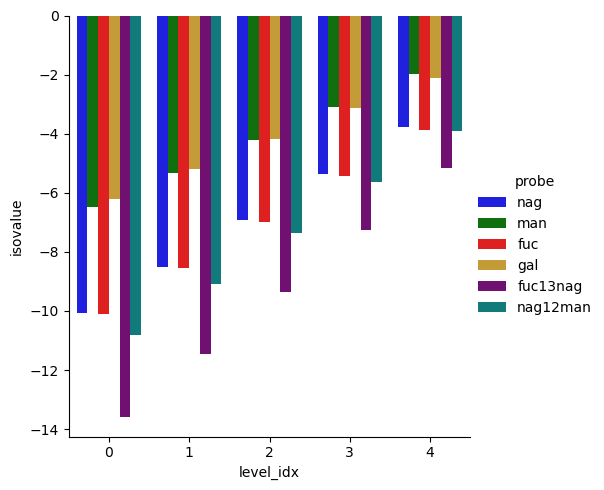

In [39]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('tetra_analysis.csv')

colors = {
    'fuc':'red',
    'fuc13nag':'purple',
    'gal':'goldenrod',
    'man':'green',
    'nag':'blue',
    'nag12man':'darkcyan'
}

sns.catplot(
    data=df,
    kind='bar',
    x='level_idx',
    y='isovalue',
    hue='probe',
    palette=colors
    )

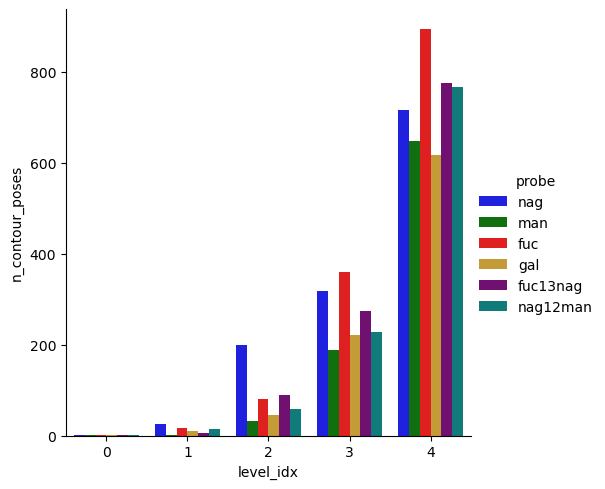

In [40]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('tetra_analysis.csv')

colors = {
    'fuc':'red',
    'fuc13nag':'purple',
    'gal':'goldenrod',
    'man':'green',
    'nag':'blue',
    'nag12man':'darkcyan'
}

sns.catplot(
    data=df,
    kind='bar',
    x='level_idx',
    y='n_contour_poses',
    hue='probe',
    palette=colors
    )

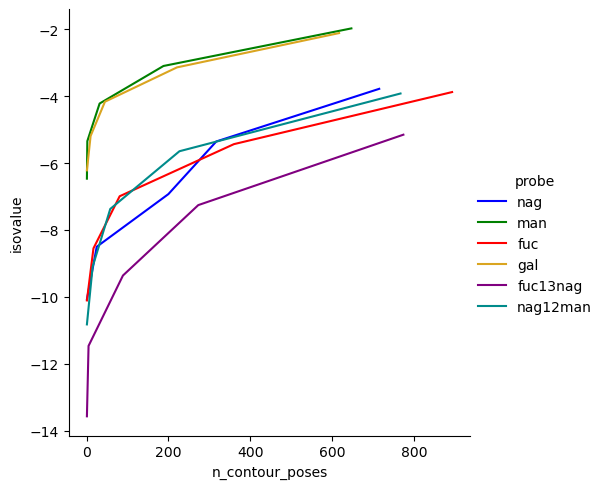

In [38]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('tetra_analysis.csv')

colors = {
    'fuc':'red',
    'fuc13nag':'purple',
    'gal':'goldenrod',
    'man':'green',
    'nag':'blue',
    'nag12man':'darkcyan'
}

sns.relplot(
    data=df,
    kind='line',
    x='n_contour_poses',
    y='isovalue',
    hue='probe',
    palette=colors
    )

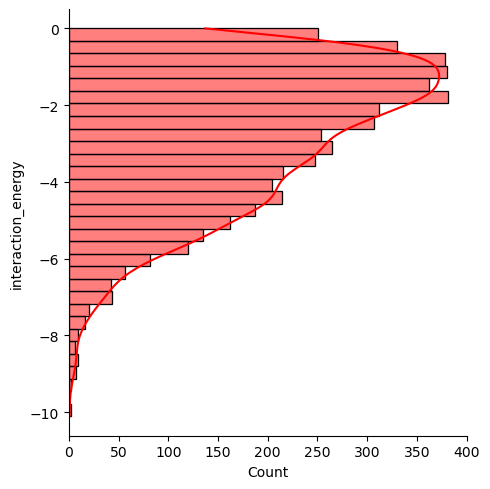

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('tetra-fuc_side_0_energy_5000p_scoredata.csv', index_col='model_num')

sns.displot(
    data=df,
    y='interaction_energy',
    color='red',
    kde=True
    )

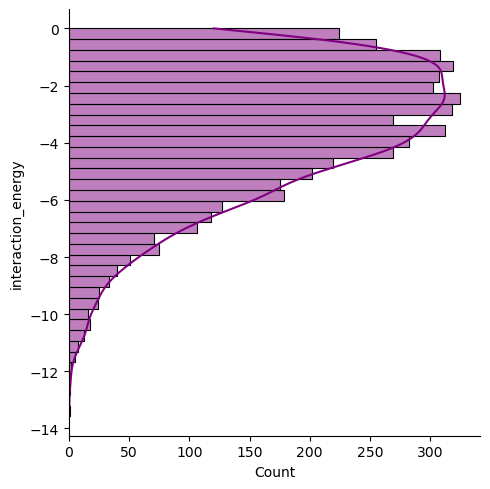

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('tetra-fuc13nag_side_0_energy_5000p_scoredata.csv', index_col='model_num')

sns.displot(
    data=df,
    y='interaction_energy',
    color='purple',
    kde=True
    )

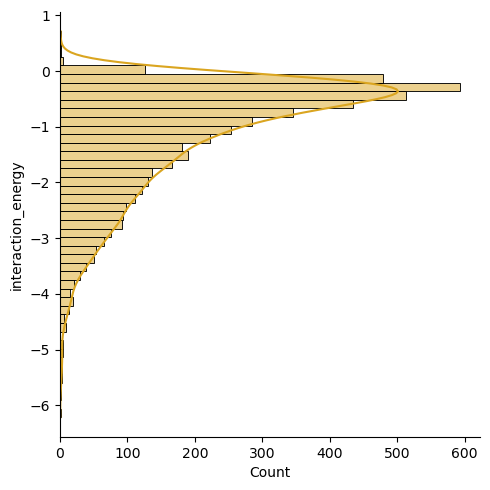

In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('tetra-gal_side_0_energy_5000p_scoredata.csv', index_col='model_num')

sns.displot(
    data=df,
    y='interaction_energy',
    color='goldenrod',
    kde=True
    )

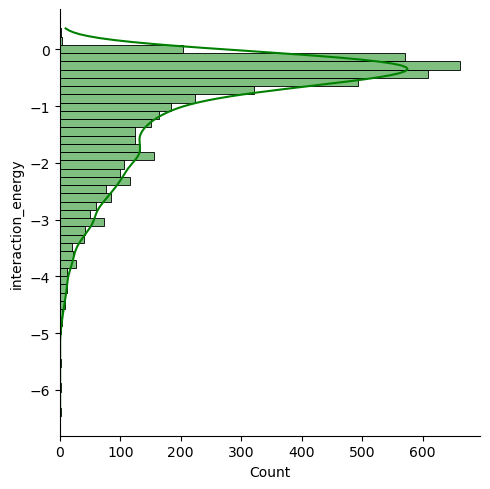

In [29]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('tetra-man_side_0_energy_5000p_scoredata.csv', index_col='model_num')

sns.displot(
    data=df,
    y='interaction_energy',
    color='green',
    kde=True
    )

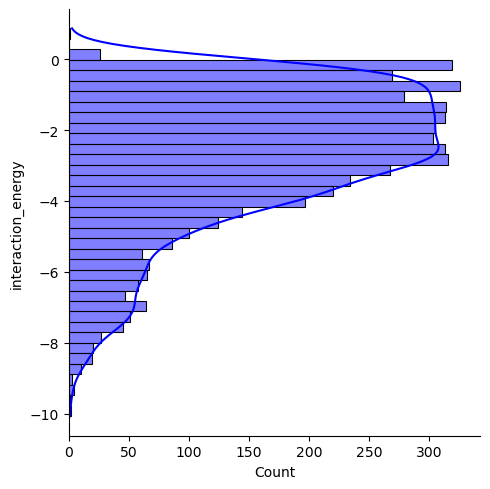

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('tetra-nag_side_0_energy_5000p_scoredata.csv', index_col='model_num')

sns.displot(
    data=df,
    y='interaction_energy',
    color='blue',
    kde=True
    )

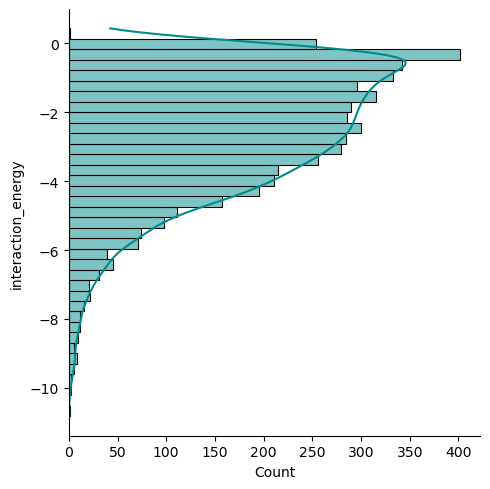

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('tetra-nag12man_side_0_energy_5000p_scoredata.csv', index_col='model_num')

sns.displot(
    data=df,
    y='interaction_energy',
    color='darkcyan',
    kde=True
    )

Append columns to each scoredata dataframe denoting receptor and probe and concatenate each into a single dataframe:

Append columns to each scoredata dataframe denoting receptor and probe and concatenate each into a single dataframe:

In [10]:
import pandas as pd
import os

df_fuc = pd.read_csv('tetra-fuc_side_0_energy_5000p_scoredata.csv')
df_fuc13nag = pd.read_csv('tetra-fuc13nag_side_0_energy_5000p_scoredata.csv')
df_gal = pd.read_csv('tetra-gal_side_0_energy_5000p_scoredata.csv')
df_man = pd.read_csv('tetra-man_side_0_energy_5000p_scoredata.csv')
df_nag = pd.read_csv('tetra-nag_side_0_energy_5000p_scoredata.csv')
df_nag12man = pd.read_csv('tetra-nag12man_side_0_energy_5000p_scoredata.csv')

df_dict = {
    'fuc':df_fuc,
    'fuc13nag':df_fuc13nag,
    'gal':df_gal,
    'man':df_man,
    'nag':df_nag,
    'nag12man':df_nag12man
}

for probe, df in df_dict.items():
    df['rec'] = 'tetra'
    df['probe'] = probe

combined_tetra_scoredata = pd.concat(df_dict.values(), ignore_index=True)
combined_tetra_scoredata.head()

,model_num,Fnat,Fnat_intf_residues,glycan_Jump_res,heavy_Lrmsd,heavy_Srmsd,interaction_energy,mc_acceptance,n_intf_res_contacts,n_intf_residues,...,n_rb_moves_made,n_tor_cycles,n_tor_moves_accepted,n_tor_moves_made,ring_Lrmsd,ring_Srmsd,pose_file,cluster_id,rec,probe
0,1,0.714286,0.714286,525.0,4.49158,4.352910e-08,-0.035372,0.5750,4.0,5.0,...,40.0,0.0,0.0,0.0,3.33416,2.433350e-08,/projects/SimBioSys/jkant/glycographer/dc-sign...,NaN,tetra,fuc
1,2,0.750000,0.750000,525.0,1.79857,4.352910e-08,-6.034060,0.3125,5.0,6.0,...,80.0,0.0,0.0,0.0,1.50922,2.269680e-07,/projects/SimBioSys/jkant/glycographer/dc-sign...,NaN,tetra,fuc
2,3,1.000000,1.000000,525.0,3.62995,4.352910e-08,-3.550600,0.2500,7.0,8.0,...,120.0,0.0,0.0,0.0,2.60710,4.866700e-08,/projects/SimBioSys/jkant/glycographer/dc-sign...,NaN,tetra,fuc
3,4,0.500000,0.500000,525.0,4.01334,6.155940e-08,-2.689560,0.2625,2.0,3.0,...,160.0,0.0,0.0,0.0,3.46844,0.000000e+00,/projects/SimBioSys/jkant/glycographer/dc-sign...,NaN,tetra,fuc
4,5,0.333333,0.333333,525.0,5.55256,6.155940e-08,-1.211400,0.3250,1.0,2.0,...,200.0,0.0,0.0,0.0,4.76785,5.960460e-08,/projects/SimBioSys/jkant/glycographer/dc-sign...,1.0,tetra,fuc


In [11]:
combined_tetra_scoredata.to_csv('tetra-allprobes_side_5000p_scoredata.csv')

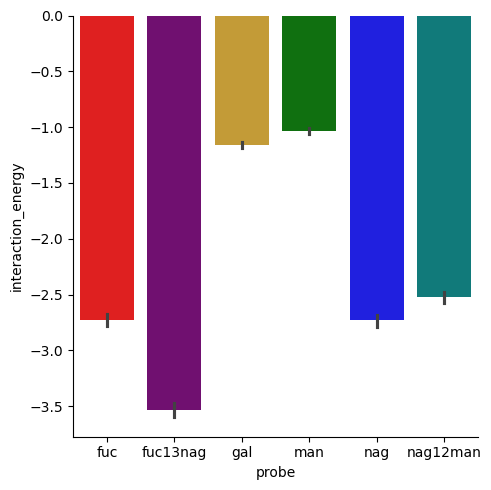

In [46]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('tetra-allprobes_side_5000p_scoredata.csv')

colors = {
    'fuc':'red',
    'fuc13nag':'purple',
    'gal':'goldenrod',
    'man':'green',
    'nag':'blue',
    'nag12man':'darkcyan'
}

sns.catplot(
    data=df,
    kind='bar',
    x='probe',
    y='interaction_energy',
    hue='probe',
    palette=colors,
    legend=False
    )

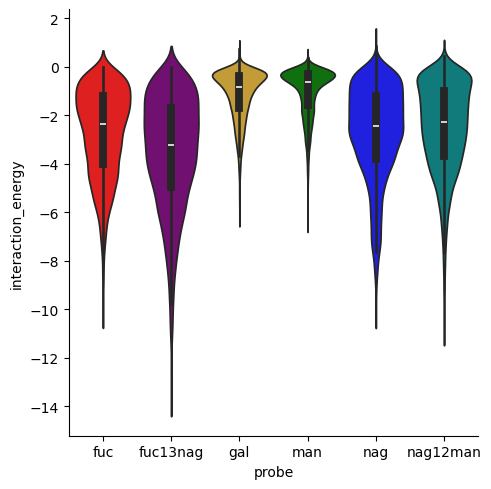

In [47]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('tetra-allprobes_side_5000p_scoredata.csv')

colors = {
    'fuc':'red',
    'fuc13nag':'purple',
    'gal':'goldenrod',
    'man':'green',
    'nag':'blue',
    'nag12man':'darkcyan'
}

sns.catplot(
    data=df,
    kind='violin',
    x='probe',
    y='interaction_energy',
    hue='probe',
    palette=colors,
    legend=False
    )

(-12.0, 0.0)

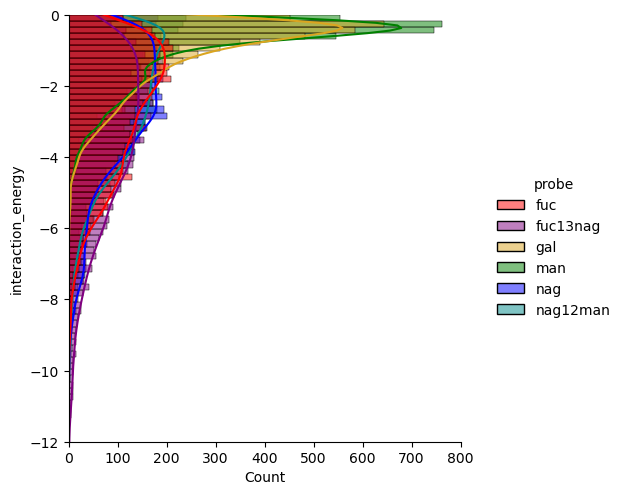

In [37]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('tetra-allprobes_side_5000p_scoredata.csv')

colors = {
    'fuc':'red',
    'fuc13nag':'purple',
    'gal':'goldenrod',
    'man':'green',
    'nag':'blue',
    'nag12man':'darkcyan'
}

sns.displot(
    data=df,
    y='interaction_energy',
    hue='probe',
    palette=colors,
    kde=True
    )

plt.ylim(-12, 0)

(-12.0, 0.0)

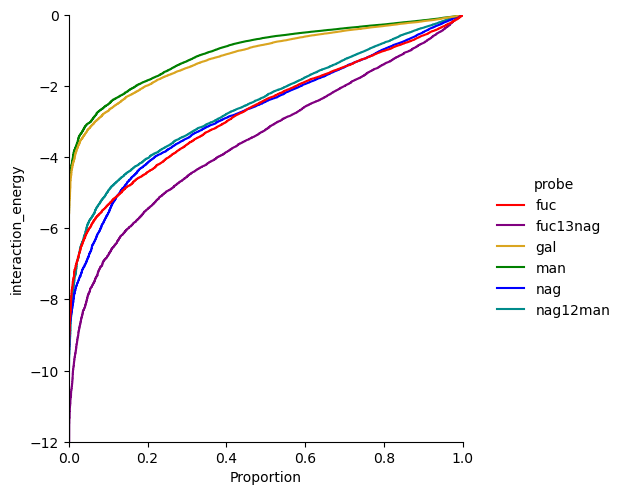

In [36]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('tetra-allprobes_side_5000p_scoredata.csv')

colors = {
    'fuc':'red',
    'fuc13nag':'purple',
    'gal':'goldenrod',
    'man':'green',
    'nag':'blue',
    'nag12man':'darkcyan'
}

sns.displot(
    data=df,
    kind='ecdf',
    y='interaction_energy',
    hue='probe',
    palette=colors,
    #rug=True
    )

plt.ylim(-12, 0)

MC acceptance rate per probe:

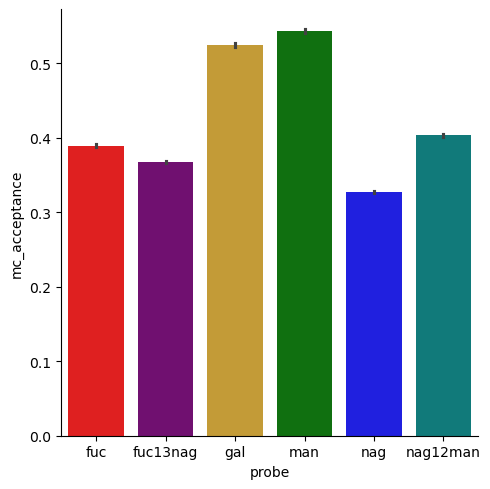

In [45]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('tetra-allprobes_side_5000p_scoredata.csv')

colors = {
    'fuc':'red',
    'fuc13nag':'purple',
    'gal':'goldenrod',
    'man':'green',
    'nag':'blue',
    'nag12man':'darkcyan'
}

sns.catplot(
    data=df,
    kind='bar',
    x='probe',
    y='mc_acceptance',
    hue='probe',
    palette=colors,
    legend=False
    )